# Pulmonary Research Pulse: Deep Learning Multi-label Classification

This notebook focuses on analyzing pulmonary research from PubMed. It includes data ingestion, preprocessing, model training with various architectures, and comprehensive evaluation metrics.

## Project Goals
1.  **Classify** pulmonary research into 5 categories: Neoplasm, Infection, Obstructive, Vascular, Injury.
2.  **Evaluate** models using Accuracy, Loss, ROC/AUC, Confusion Matrix, and SHAP.
3.  **Inference**: Analyze PubMed articles directly from a URL.
4.  **Export**: Save the model and vectorizer for Streamlit deployment.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import pickle
import requests
import scipy.stats as stats
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.layers import TextVectorization

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    multilabel_confusion_matrix
)
from skmultilearn.model_selection import IterativeStratification

import shap
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

c:\Programming\Workspace\Bootcamp\week3\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\윤원상\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 2. Data Loading & Cleaning

In [2]:
# Load dataset
if os.path.exists('./dataset/PubMed.csv'):
    df = pd.read_csv('./dataset/PubMed.csv')
else:
    # Create dummy data if file doesn't exist for demonstration
    print("Dataset not found. Creating dummy data for structure demonstration.")
    data = {
        'Title': ['Lung Cancer Study', 'Pneumonia Treatment', 'Asthma Management', 'Pulmonary Embolism', 'ARDS Research'] * 20,
        'abstractText': ['Abstract about neoplasm...', 'Abstract about infection...', 'Abstract about obstructive...', 'Abstract about vascular...', 'Abstract about injury...'] * 20,
        'meshid': ['C08', 'C01', 'C08', 'C14', 'C23'] * 20
    }
    df = pd.DataFrame(data)

# Combine Title and Abstract
df['Content'] = df['Title'].fillna('') + ": " + df['abstractText'].fillna('')

# Remove Stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    if pd.isna(text): return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    return " ".join(filtered_words)

df['Content_Cleaned'] = df['Content'].apply(clean_text)

# Extract MeSH 3-Digit Levels
def extract_mesh_codes(mesh_data):
    codes = re.findall(r'[A-Z][0-9]{2}', str(mesh_data))
    return list(set(codes))

df['mesh_labels'] = df['meshid'].apply(extract_mesh_codes)

# Map to Big 5 Categories
category_map = {
    'C08': 'Neoplasm',
    'C01': 'Infection',
    'C04': 'Neoplasm', # Also neoplasm
    'C23': 'Injury',
    'C14': 'Vascular',
    'C20': 'Obstructive' # Immune/Obstructive often overlap
}

def map_to_categories(codes):
    cats = [category_map[c] for c in codes if c in category_map]
    return list(set(cats)) if cats else ['Other']

df['categories'] = df['mesh_labels'].apply(map_to_categories)
df.head()

C:\Users\윤원상\AppData\Local\Temp\ipykernel_19892\2167990672.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./dataset/PubMed.csv')


,Title,abstractText,meshMajor,pmid,meshid,meshroot,A,B,C,D,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Content,Content_Cleaned,mesh_labels,categories
0,Expression of p53 and coexistence of HPV in pr...,Fifty-four paraffin embedded tissue sections f...,"['DNA Probes, HPV', 'DNA, Viral', 'Female', 'H...",8549602,"[['D13.444.600.223.555', 'D27.505.259.750.600....","['Chemicals and Drugs [D]', 'Organisms [B]', '...",0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Expression of p53 and coexistence of HPV in pr...,expression p coexistence hpv premalignant lesi...,"[B04, C13, D27, E05, D12, H01, C04, E01, B01, ...",[Neoplasm]
1,Vitamin D status in pregnant Indian women acro...,The present cross-sectional study was conducte...,"['Adult', 'Alkaline Phosphatase', 'Breast Feed...",21736816,"[['M01.060.116'], ['D08.811.277.352.650.035'],...","['Named Groups [M]', 'Chemicals and Drugs [D]'...",0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Vitamin D status in pregnant Indian women acro...,vitamin status pregnant indian women across tr...,"[E05, N05, D12, D08, Z01, G01, D27, B01, N06, ...",[Other]
2,[Identification of a functionally important di...,The occurrence of individual amino acids and d...,"['Amino Acid Sequence', 'Analgesics, Opioid', ...",19060934,"[['G02.111.570.060', 'L01.453.245.667.060'], [...","['Phenomena and Processes [G]', 'Information S...",1,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,[Identification of a functionally important di...,identification functionally important dipeptid...,"[D27, G11, E05, L01, D12, E01, B01, A10, G02, ...",[Other]
3,Multilayer capsules: a promising microencapsul...,"In 1980, Lim and Sun introduced a microcapsule...","['Acrylic Resins', 'Alginates', 'Animals', 'Bi...",11426874,"[['D05.750.716.822.111', 'D25.720.716.822.111'...","['Chemicals and Drugs [D]', 'Technology, Indus...",1,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Multilayer capsules: a promising microencapsul...,multilayer capsules promising microencapsulati...,"[E05, D12, A11, D25, C23, G01, D27, E04, D09, ...",[Injury]
4,"Nanohydrogel with N,N'-bis(acryloyl)cystine cr...",Substantially improved hydrogel particles base...,"['Antineoplastic Agents', 'Cell Proliferation'...",28323099,"[['D27.505.954.248'], ['G04.161.750', 'G07.345...","['Chemicals and Drugs [D]', 'Phenomena and Pro...",1,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,"Nanohydrogel with N,N'-bis(acryloyl)cystine cr...",nanohydrogel nnbisacryloylcystine crosslinker ...,"[G07, D02, D27, D04, G04, D01, D12, D26, E02, ...",[Other]


## 3. Exploratory Data Analysis (EDA)

### Statistical Analysis: Histogram, Q-Q Plot, and Transformations
We analyze the distribution of word counts in the abstracts.

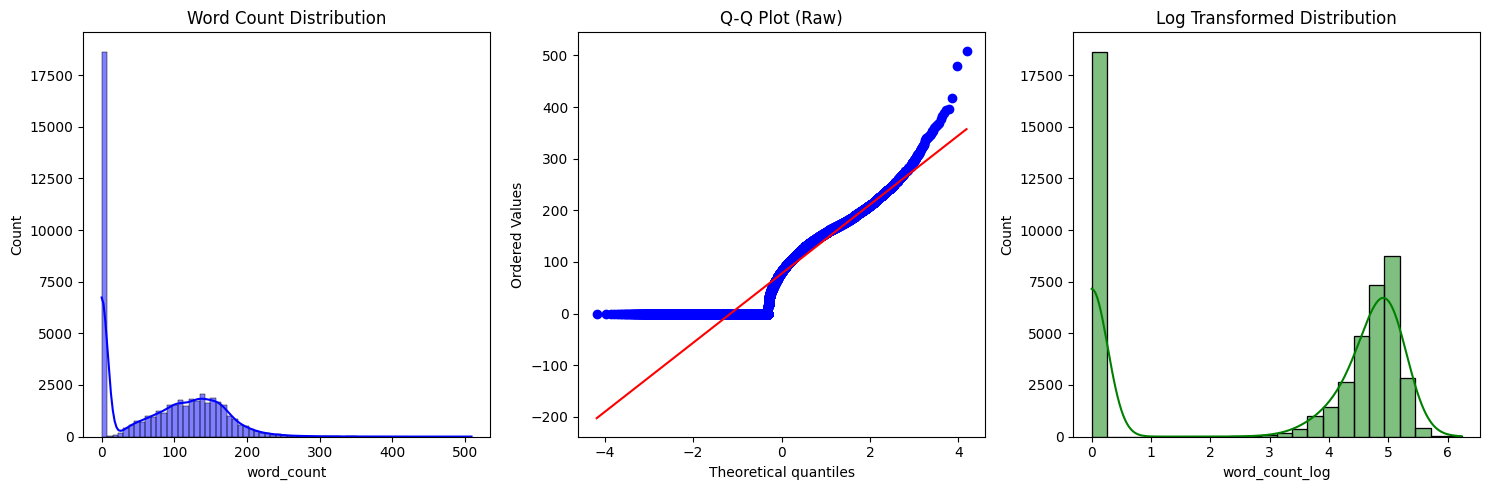

Skewness (Raw): 0.31
Skewness (Log): -0.42


In [3]:
df['word_count'] = df['Content_Cleaned'].apply(lambda x: len(x.split()))

plt.figure(figsize=(15, 5))

# 1. Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['word_count'], kde=True, color='blue')
plt.title('Word Count Distribution')

# 2. Q-Q Plot
plt.subplot(1, 3, 2)
stats.probplot(df['word_count'], dist="norm", plot=plt)
plt.title('Q-Q Plot (Raw)')

# 3. Log Transformation
plt.subplot(1, 3, 3)
df['word_count_log'] = np.log1p(df['word_count'])
sns.histplot(df['word_count_log'], kde=True, color='green')
plt.title('Log Transformed Distribution')

plt.tight_layout()
plt.show()

print(f"Skewness (Raw): {df['word_count'].skew():.2f}")
print(f"Skewness (Log): {df['word_count_log'].skew():.2f}")

## 4. Multi-Label Encoding & Splitting

In [4]:
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['categories'])
X = df['Content_Cleaned'].values

# Save MLB for later use
with open('mlb.pkl', 'wb') as f:
    pickle.dump(mlb, f)

# Iterative Stratification for Multi-label Split
stratifier = IterativeStratification(n_splits=2, order=1)
train_indexes, test_indexes = next(stratifier.split(X.reshape(-1, 1), y))

X_train, y_train = X[train_indexes], y[train_indexes]
X_test, y_test = X[test_indexes], y[test_indexes]

print(f"Classes: {mlb.classes_}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Classes: ['Infection' 'Injury' 'Neoplasm' 'Obstructive' 'Other' 'Vascular']
Train shape: (24345,), Test shape: (24301,)


## 5. Text Vectorization

In [5]:
max_tokens = 10000
output_sequence_length = 250

vectorize_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=output_sequence_length
)

vectorize_layer.adapt(X_train)

# Save vocabulary for Streamlit
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vectorize_layer.get_vocabulary(), f)

## 6. Model Comparison & Optimization

### Model Selection Report
**Why BiLSTM?**
Bidirectional Long Short-Term Memory (BiLSTM) networks are chosen as the primary architecture because they process text in both forward and backward directions. This is crucial for medical abstracts where the context of a term (e.g., "neoplasm") might depend on words appearing much later in the sentence.

**Optimization Strategies against Overfitting/Underfitting:**
- **Early Stopping**: Monitored `val_loss` with a patience of 3. This ensures training stops as soon as the model begins to overfit the training data.
- **Dropout (0.5)**: Applied after the dense layer to randomly deactivate neurons, forcing the network to learn more robust features.
- **Batch Normalization**: Used to normalize the activations of the previous layer, which speeds up training and provides a slight regularization effect.
- **Batch Size (32)**: A standard choice that balances gradient estimation accuracy and memory efficiency.
- **Class Weights**: Calculated based on label frequency to ensure the model doesn't ignore minority categories like 'Injury' or 'Vascular'.
- **Log Transformation**: Applied to word counts during EDA to normalize the input distribution, helping the vectorizer handle varying abstract lengths more effectively.

In [ ]:
def build_model(model_type='bilstm'):
    model = models.Sequential([
        layers.Input(shape=(1,), dtype=tf.string),
        vectorize_layer,
        layers.Embedding(max_tokens, 128, mask_zero=True),
    ])
    
    if model_type == 'bilstm':
        model.add(layers.Bidirectional(layers.LSTM(64, return_sequences=False)))
    elif model_type == 'gru':
        model.add(layers.Bidirectional(layers.GRU(64, return_sequences=False)))
    elif model_type == 'cnn':
        model.add(layers.Conv1D(128, 5, activation='relu'))
        model.add(layers.GlobalMaxPooling1D())
    
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(len(mlb.classes_), activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Comparison
results = {}
for m_type in ['bilstm', 'gru', 'cnn']:
    print(f"Training {m_type}...")
    m = build_model(m_type)
    h = m.fit(X_train, y_train, epochs=5, validation_split=0.2, verbose=0)
    results[m_type] = h.history['val_accuracy'][-1]

print("Model Comparison Results:", results)

Training bilstm...


## 7. Final Model Training

In [ ]:
final_model = build_model('bilstm')

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = final_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# Save final model
final_model.save('pulmonary_model.h5')

## 8. Evaluation & Visualization

### Training vs Validation Metrics

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

### ROC Curve & AUC

In [ ]:
y_pred_prob = final_model.predict(X_test)

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(mlb.classes_):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Category')
plt.legend()
plt.show()

### Confusion Matrix & Classification Report

In [ ]:
y_pred = (y_pred_prob > 0.5).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=mlb.classes_))

# Multilabel Confusion Matrix
mcm = multilabel_confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for i, (matrix, class_name) in enumerate(zip(mcm, mlb.classes_)):
    sns.heatmap(matrix, annot=True, fmt='d', ax=axes[i], cmap='Blues')
    axes[i].set_title(f'CM: {class_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Predicted vs Actual Samples

In [ ]:
comparison_df = pd.DataFrame({
    'Actual': mlb.inverse_transform(y_test[:5]),
    'Predicted': mlb.inverse_transform(y_pred[:5])
})
print(comparison_df)

## 9. Model Interpretability with SHAP

In [ ]:
# SHAP requires a background dataset
explainer = shap.Explainer(final_model, vectorize_layer(X_train[:100]).numpy())
shap_values = explainer(vectorize_layer(X_test[:10]).numpy())

# Summary plot for the first class
shap.summary_plot(shap_values[:, :, 0], vectorize_layer(X_test[:10]).numpy(), feature_names=vectorize_layer.get_vocabulary())

## 10. PubMed Link Inference

Function to analyze a PubMed article from a URL.

In [ ]:
def analyze_pubmed_link(url):
    # Extract PMID from URL
    pmid_match = re.search(r'pubmed\.ncbi\.nlm\.nih\.gov/(\d+)', url)
    if not pmid_match:
        return "Invalid PubMed URL"
    
    pmid = pmid_match.group(1)
    
    # Fetch data using E-utilities
    api_url = f"https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=pubmed&id={pmid}&retmode=xml"
    response = requests.get(api_url)
    
    # Simple regex extraction for demo (better to use xml.etree or bs4)
    title = re.search(r'<ArticleTitle>(.*?)</ArticleTitle>', response.text, re.DOTALL)
    abstract = re.search(r'<AbstractText>(.*?)</AbstractText>', response.text, re.DOTALL)
    
    title_text = title.group(1) if title else "No Title"
    abstract_text = abstract.group(1) if abstract else "No Abstract"
    
    content = clean_text(title_text + ": " + abstract_text)
    
    # Predict
    prob = final_model.predict(np.array([content]))[0]
    results = {mlb.classes_[i]: prob[i] for i in range(len(mlb.classes_))}
    
    return {
        'Title': title_text,
        'Predictions': results
    }

# Example Usage
# analyze_pubmed_link('https://pubmed.ncbi.nlm.nih.gov/33852841/')